# Code deformation for [144, 12, 6] BB code

In [1]:
import graph_helper_functions
from graph_helper_functions import *
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import igraph as ig
from igraph import plot
from sympy.abc import x, y
from qldpc import codes, circuits
from qldpc.objects import Pauli
import numpy as np
from collections import defaultdict, deque

## Example for a logical Z

144
BB code with [n, k, d] = [72, 12, 6]
Logical qubit indices:  [ 5  6  7 10 11 12 13 16 17 24 30 36 37 56]
Port vertice indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13]
Edges added to auxiliary system:  21
Weight of new X stabilizers:  [3, 3, 4, 4, 5, 5, 6, 6]
Weight of new Z stabilizers:  [4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
The deformed BB code: 
Qubits: [0,1, ... 92] with 72 original BB code qubits [0, 1, ..., 71] and 21 added edge qubits [72, 73, ... 92]
Parity check matrix H_def of size (94, 186): 
[[0 1 1 ... 0 0 0]
 [0 0 1 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 1 0 0]
 [0 0 0 ... 0 0 0]]


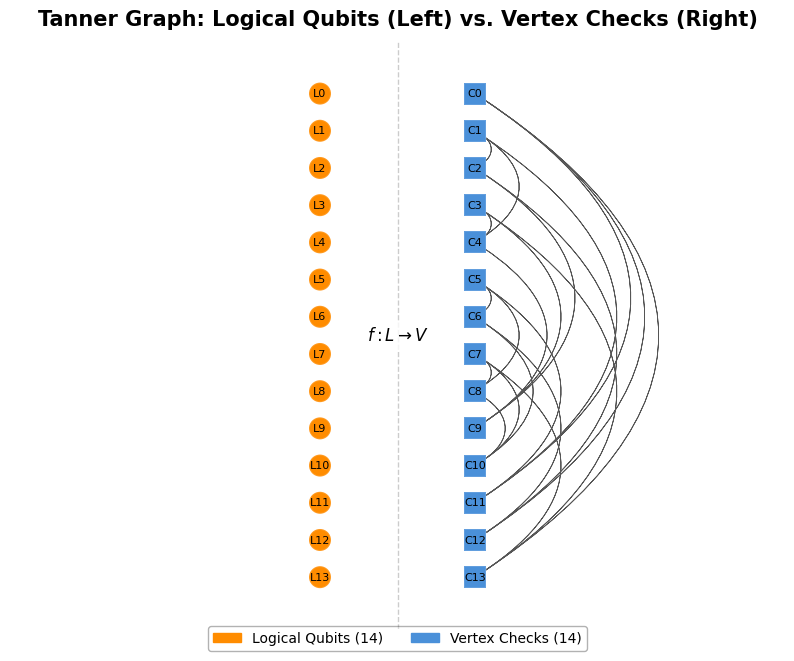

In [2]:
a = x**3+y+y**2
b = y**3+x+x**2
orders = {x: 6, y: 6}
BB_code = codes.BBCode(orders=orders, poly_a=a, poly_b=b)
print(len(BB_code.matrix[0]))
print("BB code with [n, k, d] = [72, 12, 6]")
logicals = BB_code.get_logical_ops(Pauli.Z)
# logical qubits, set "L"
logical_qubits = logicals[0]
logical_qubits_index = np.where(logicals[0] == 1)[0]
n_L = len(logical_qubits_index)

# syndrome measurements from parity check matrix
port_vertices = np.array(range(len(logical_qubits_index)))
n_L = len(logical_qubits_index)
n_vertices = 2*n_L  # this includes port vertices + qubits in the graph 
g = ig.Graph(n_vertices, edges = [])

g["title"] = "Logical Qubits and Vertex Checks"
g.vs["is_logical"] = [True] * n_L + [False] * n_L
g.vs["label"]      = [f"L{i}" for i in range(n_L)] + [f"C{i}" for i in range(n_L)]
g.vs["is_check"] = [False] * n_L + [True] * n_L

print("Logical qubit indices: ", logical_qubits_index)
print("Port vertice indices:", port_vertices)

# Spacing constants
COLUMN_GAP = 5  # Horizontal distance between the two lines
VERTICAL_STEP = 1.2  # Vertical distance between nodes in a line

total_height = (n_L - 1) * VERTICAL_STEP
y_center = total_height / 2

logical_x = 0
logical_positions = [
    (logical_x, y_center - i * VERTICAL_STEP) 
    for i in range(n_L)
]

check_x = logical_x + COLUMN_GAP
check_positions = [
    (check_x, y_center - i * VERTICAL_STEP) 
    for i in range(n_L)
]

layout = ig.Layout(logical_positions + check_positions)

vertex_colors = ["#FF8C00" if v["is_logical"] else "#4A90D9" for v in g.vs]
vertex_sizes  = [22 for v in g.vs]
vertex_shapes = ["rectangle" if v["is_check"] else "circle" for v in g.vs]

BB_qubit_vertex_check_map = mapping = {val: i for i, val in enumerate(logical_qubits_index)}

def f(q):
    return q + n_L

def f_inverse(q):
    return q-n_L

# compute which vertices should be connected based on anticommutation with X checks
checks = BB_code.matrix
X_checks = checks[:, :72]


X_check_pairs = []
for i, check in enumerate(X_checks):
    pair = np.where((logical_qubits == 1) & (check == 1))[0] 
    if len(pair) == 2:
        (v1, v2) = pair
        v1 = BB_qubit_vertex_check_map[v1]
        v2 = BB_qubit_vertex_check_map[v2]
        X_check_pairs.append((f(v1), f(v2)))


for pair in X_check_pairs:
    g.add_edge(*pair)

n_edges = len(g.get_edgelist())
print("Edges added to auxiliary system: ", n_edges)



fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.set_aspect('equal')

ig.plot(
    g,
    target=ax,
    layout=layout,
    vertex_size=vertex_sizes,
    vertex_color=vertex_colors,
    vertex_shape = vertex_shapes,
    vertex_frame_width=1.5,
    vertex_frame_color="#ffffff22",
    vertex_label=g.vs["label"] if "label" in g.vs.attributes() else None,
    vertex_label_size=8.0,
    vertex_label_color="black",
    edge_width=0.6,
    edge_curved=[1]*n_L,
    edge_color="#555555"       
    
)
all_x = [pos[0] for pos in logical_positions + check_positions]
all_y = [pos[1] for pos in logical_positions + check_positions]
padding = 10
ax.set_xlim(min(all_x) - padding, max(all_x) + padding)

y_mid = (min(all_y) + max(all_y)) / 2

# Dividing line exactly in the middle
div_x = logical_x + (COLUMN_GAP / 2)
ax.axvline(x=div_x, color="#00000033", linewidth=1, linestyle="--")

ax.text(
    div_x, y_mid, r'$f: L \to V$',
    ha='center', va='center',
    fontsize=12,
    bbox=dict(facecolor='white', edgecolor='none', alpha=0.8)
)

ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

# Legend
legend_handles = [
    mpatches.Patch(color="#FF8C00", label=f"Logical Qubits ({n_L})"),
    mpatches.Patch(color="#4A90D9", label=f"Vertex Checks ({n_L})"),
]
ax.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=2,
    framealpha=0.3,
    facecolor="white",           
    edgecolor="#00000033",      
    labelcolor="black",          
    fontsize=10,
)

ax.set_title(
    "Tanner Graph: Logical Qubits (Left) vs. Vertex Checks (Right)",
    color="black", fontsize=15, pad=12, fontweight="bold"
)

#print(stimcode)
edge_qubits = np.arange(n_edges)
cycles_edges = find_short_cycle_basis([tuple(a) for a in X_check_pairs], return_edges=True)
new_X_syndromes = []
for cyc in cycles_edges:
    support = []
    for u, v in cyc:
        eid = g.get_eid(u, v, directed=False)
        support.append(72 + eid)
    new_X_syndromes.append(support)

# BB code qubits [0, 71] + Ancillary system [72, ]
BB_qubits = np.arange(72)
ancilla_qubits = np.arange(72, 72+n_edges)
ancilla_system = np.arange(72+n_edges)

new_Z_syndromes = []
for v in range(n_vertices//2, 28):  # vertices 13–27 (0-based)
    Z_check = g.incident(v)  
    Z_check = [i + 72 for i in Z_check] # add edge qubits touching vertex
    Z_check.append(int(logical_qubits_index[f_inverse(v)])) # add logical support qubit 
    new_Z_syndromes.append(Z_check)


# print(new_X_syndromes[0])
# print(new_Z_syndromes)

print("Weight of new X stabilizers: ", sorted([len(i) for i in new_X_syndromes])) # paper had  [3, 3, 5, 5, 5, 6, 7, 9]. We should put an upper limit 
print("Weight of new Z stabilizers: ", sorted([len(i) for i in new_Z_syndromes]))
n_data = 72
n_qubits = n_data + n_edges

checks = np.array(BB_code.matrix, dtype=int)

Hx_all = checks[:, :n_data]
Hz_all = checks[:, n_data:]

Hx_old = Hx_all[np.any(Hx_all, axis=1)]
Hz_old = Hz_all[np.any(Hz_all, axis=1)]

Hx_new = np.zeros((len(new_X_syndromes), n_qubits), dtype=int)
for i, support in enumerate(new_X_syndromes):
    Hx_new[i, support] = 1

Hz_new = np.zeros((len(new_Z_syndromes), n_qubits), dtype=int)
for i, support in enumerate(new_Z_syndromes):
    Hz_new[i, support] = 1

Hx_old_padded = deform_old_x_checks_with_graph_edges(
    g=g,
    Hx_all=Hx_all,
    logical_qubits=logical_qubits,
    logical_qubits_index=logical_qubits_index,
    n_data=72,
    n_edges=n_edges,
    n_L=n_L,
)
Hz_old_padded = np.pad(Hz_old, ((0, 0), (0, n_edges)), mode="constant")

Hx_def = np.vstack([Hx_old_padded, Hx_new])
Hz_def = np.vstack([Hz_old_padded, Hz_new])
H_def = np.block([[Hx_def, np.zeros((np.shape(Hx_def)[0], n_qubits), dtype=int)], [np.zeros((np.shape(Hz_def)[0], n_qubits), dtype=int), Hz_def]])

print("The deformed BB code: ")
print(f"Qubits: [0,1, ... {n_qubits-1}] with {n_data} original BB code qubits [0, 1, ..., {n_data-1}] and {n_edges} added edge qubits [{n_data}, {n_data+1}, ... {n_qubits-1}]")
print(f"Parity check matrix H_def of size {np.shape(H_def)}: ")
print(H_def)

In [3]:

comm = (Hz_def @ Hx_def.T) % 2
print("Deformed stabilizers commute? ", np.all(comm==0))
deformed_logical = np.pad(logical_qubits, (0, n_edges))

Deformed stabilizers commute?  True


In [4]:
comm = (Hz_def @ Hx_def.T) % 2
print("Deformed stabilizers commute? ", np.all(comm==0))
deformed_logical = np.pad(logical_qubits, (0, n_edges))
coeffs = gf2_solve_left(Hz_def, deformed_logical)

print("Original logical is in stabilizer group:", np.any(coeffs==1))
print("Combination of checks:", np.where(coeffs == 1)[0])
# recon = (coeffs @ Hz_def) % 2
# print("Reconstruction correct?", np.array_equal(recon, deformed_logical % 2))

Deformed stabilizers commute?  True
Original logical is in stabilizer group: True
Combination of checks: [36 37 38 39 40 41 42 43 44 45 46 47 48 49]


# Auxiliary graph measurement of logical

In [5]:
import graph_helper_functions
from graph_helper_functions import *
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import igraph as ig
from sympy.abc import x, y
from qldpc import codes, circuits
from qldpc.objects import Pauli
import numpy as np
from collections import defaultdict, deque
from collections import defaultdict


def deform_code_for_logical(H, basis, logical):
    logical_qubits_index = np.where(logical == 1)[0]
    n_data = logical.shape[0]
    qubit_to_vertex = {int(q): i for i, q in enumerate(logical_qubits_index)}
    vertex_to_qubit = {i: int(q) for i, q in enumerate(logical_qubits_index)}
    n_vertices = len(logical_qubits_index)
    g = ig.Graph(n_vertices, edges=[])

    if basis == Pauli.Z:
        H_basis_all = H[:, n_data:]
        H_opposite_basis_all = H[:, :n_data]
    else:
        H_basis_all = H[:, :n_data]
        H_opposite_basis_all = H[:, n_data:]

    edge_set = set()
    
    for check in H_opposite_basis_all:
        overlap = np.where((logical == 1) & (check == 1))[0]
        if len(overlap)>0 and len(overlap)%2==0:
            n_pairs = len(overlap) // 2
            for i in range(n_pairs):
                v1 = qubit_to_vertex[int(overlap[2*i])]
                v2 = qubit_to_vertex[int(overlap[2*i+1])]
                edge_set.add(normalize_edge(v1, v2))

    if edge_set:
        g.add_edges(list(edge_set))


    comps = g.components()
    if len(comps) > 1:
        reps = [comp[0] for comp in comps]
        for i in range(len(reps) - 1):
            e = normalize_edge(reps[i], reps[i + 1])
            if not g.are_adjacent(*e):
                g.add_edge(*e)
    #print_degree_stats(g, "after adding edges")

    H_basis_nonzero = H_basis_all[np.any(H_basis_all, axis=1)]
    max_cycle_weight = int(np.max(np.sum(H_basis_nonzero, axis=1))) if len(H_basis_nonzero) else 4
    max_cycle_weight = max(max_cycle_weight, 3)

    cycles_edges = find_short_cycle_basis(
        [tuple(map(int, e)) for e in g.get_edgelist()],
        return_edges=True,
    )
    #print_degree_stats(g, "Before splitting cycles")
    cycles_edges = split_heavy_cycles(
        cycles_edges=cycles_edges,
        max_cycle_weight=max_cycle_weight,
        g=g,
    )
    #print_degree_stats(g, "After splitting cycles")
    final_edgelist = [normalize_edge(*e) for e in g.get_edgelist()]
    edge_to_eid = {e: eid for eid, e in enumerate(final_edgelist)}

    n_edges = len(final_edgelist)
    n_qubits = n_data + n_edges

    H_opposite_basis_new = np.zeros((len(cycles_edges), n_qubits), dtype=np.uint8)
    for i, cyc in enumerate(cycles_edges):
        for e in cyc:
            eid = edge_to_eid[normalize_edge(*e)]
            H_opposite_basis_new[i, n_data + eid] ^= 1

    H_basis_new = np.zeros((n_vertices, n_qubits), dtype=np.uint8)
    for v in range(n_vertices):
        H_basis_new[v, vertex_to_qubit[v]] = 1
        for eid in g.incident(v):
            H_basis_new[v, n_data + eid] ^= 1

    H_basis_old = H_basis_all[np.any(H_basis_all, axis=1)]
    H_basis_old_padded = np.pad(H_basis_old, ((0, 0), (0, n_edges)), mode="constant").astype(np.uint8)

    H_opposite_basis_old_padded = deform_old_opposite_basis_checks_with_graph_edges(
        g=g,
        H_opposite_basis_all=H_opposite_basis_all,
        logical_qubits=logical,
        logical_qubits_index=logical_qubits_index,
        n_data=n_data,
    )

    H_opposite_basis_def = np.vstack([H_opposite_basis_old_padded, H_opposite_basis_new]) % 2
    H_basis_def = np.vstack([H_basis_old_padded, H_basis_new]) % 2

    res = {
        "n_qubits" : n_qubits,
        "n_original_qubits" : n_data,
        "n_edges" : n_edges,
        "H_basis_def" : H_basis_def,
        "H_opposite_basis_def" : H_opposite_basis_def,
        "H_basis_new" : H_basis_new,
        "H_basis_old" : H_basis_old_padded,
        "H_opposite_basis_new" : H_opposite_basis_new,
        "H_opposite_basis_old_padded" : H_opposite_basis_old_padded,
        "g" : g,
        "logical" : logical,
        "qubit_to_vertex": qubit_to_vertex
    }
    
    return res

a = x**3+y+y**2
b = y**3+x+x**2
orders = {x: 6, y: 6}
BB_code = codes.BBCode(orders=orders, poly_a=a, poly_b=b)

deformation_result = deform_code_for_logical(BB_code.matrix, Pauli.Z, BB_code.get_logical_ops(Pauli.Z)[0])


In [6]:
# validate graphs for BB code
code = codes.SurfaceCode(4, 4)
deformation_result = deform_code_for_logical(code.matrix, Pauli.Z, code.get_logical_ops(Pauli.Z)[0])
plot(deformation_result["g"])

def max_stabilizer_weight(H_basis_def, H_opposite_basis_def):
    H = np.concatenate((H_basis_def, H_opposite_basis_def), axis=0)
    return np.max(np.sum(H==1, axis=1))
    
def max_qubit_degree(H_basis_def, H_opposite_basis_def):
    H = np.concatenate((H_basis_def, H_opposite_basis_def), axis=0)
    return np.max(np.sum(H, axis=0))

def is_connected(g):
    return g.is_connected()


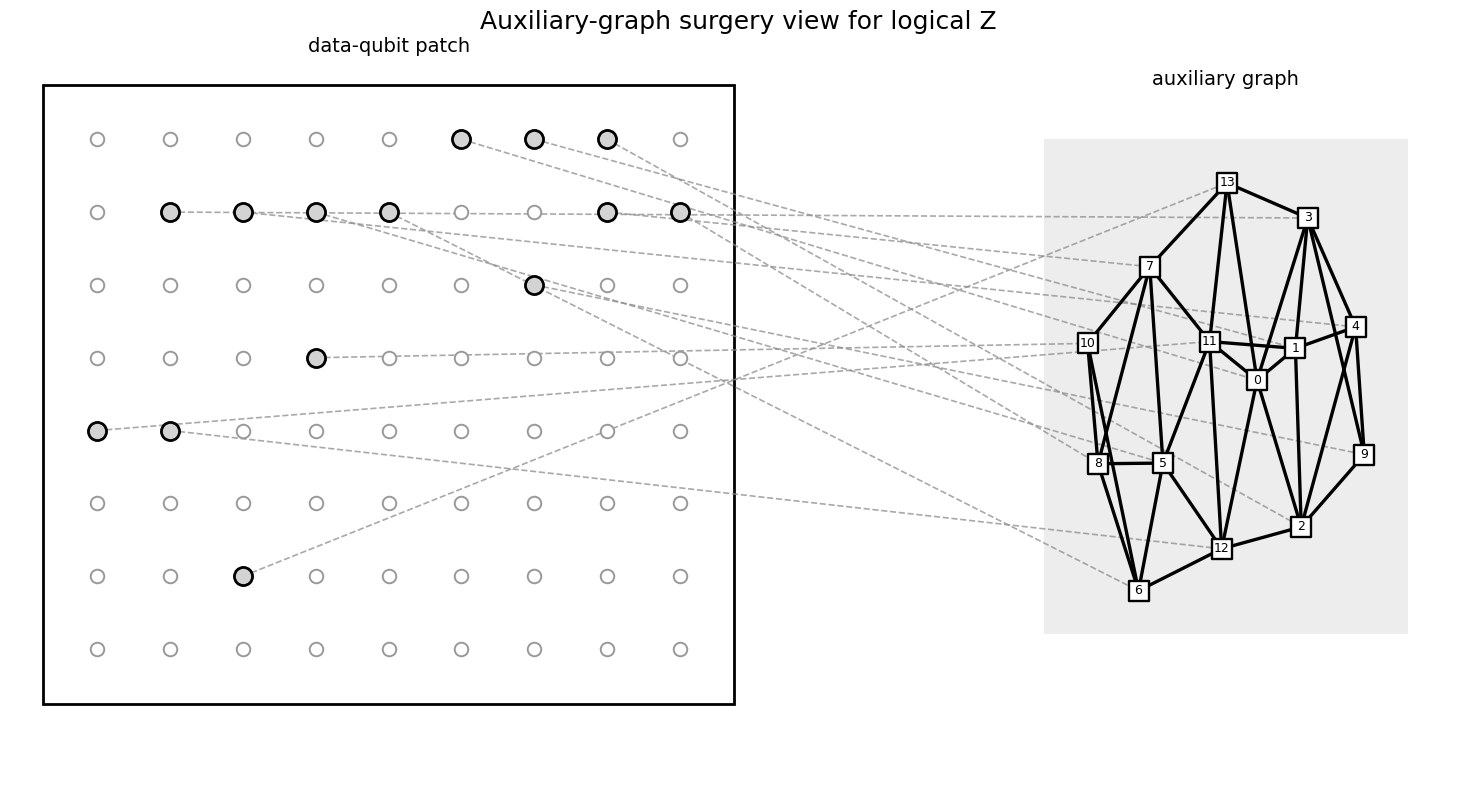

In [7]:
fig, ax, deformation = plot_deformation_surgery_view(
    BB_code.matrix,
    Pauli.Z,
    BB_code.get_logical_ops(Pauli.Z)[0],
    n_cols=9,
)

plt.show()

In [9]:
# functions for evaluating surgery protocol satisfying desiderata (1-4) in paper (page 7)
def relative_expansion_exact(g: ig.Graph, distance):
    n = g.vcount()
    G = np.zeros((g.ecount(), n), dtype=np.uint8)
    for eid, (u, v) in enumerate(g.get_edgelist()):
        G[eid, u] = 1
        G[eid, v] = 1
    beta = float("inf")
    for mask in range(1 << n):
        v = np.array([(mask >> i) & 1 for i in range(n)], dtype=np.uint8)
        size = int(np.sum(v))
        denom = min(distance, size, n - size)
        if denom == 0:
            continue
        boundary = int(np.sum((v @ G.T) % 2))
        beta = min(beta, boundary / denom)
    return beta

def max_syndrome_acting_on_qubit(H_basis_def, H_opposite_basis_def):
    """
    Returns the maximum column weight (i.e., max number of checks
    acting on any qubit) across both parity-check matrices.
    """
    col_weights = np.sum(H_basis_def, axis=0) + np.sum(H_opposite_basis_def, axis=0)
    max_col_weight = int(np.max(col_weights)) if col_weights.size > 0 else 0
    return max_col_weight

def max_syndrome_row_weight(H_basis_def, H_opposite_basis_def):
    """
    Returns the maximum row weight (i.e., max number of qubits
    acted on by any check) across both parity-check matrices.
    """

    # Row weights = number of 1s per row
    row_weights_basis = np.sum(H_basis_def, axis=1)
    row_weights_opposite = np.sum(H_opposite_basis_def, axis=1)
    # Combine both
    all_row_weights = np.concatenate([row_weights_basis, row_weights_opposite])
    if all_row_weights.size == 0:
        return 0
    return int(np.max(all_row_weights))

def g_connected(g):
    return g.is_connected()
    

## Merge by auxiliary surgery with adapter qubits

In [10]:
def auxiliary_merge(deformation_result1, deformation_result2):
    g1 = deformation_result1["g"]
    g2 = deformation_result2["g"]
    
    n_v1 = g1.vcount()
    n_v2 = g2.vcount()

    n_q1 = deformation_result1["n_qubits"]
    n_q2 = deformation_result2["n_qubits"]

    n_data1 =  deformation_result1["n_original_qubits"]
    n_data2 =  deformation_result2["n_original_qubits"]

    n_edges1 = deformation_result1["n_edges"]
    n_edges2 = deformation_result2["n_edges"]

    if n_v1 != n_v2:
        raise ValueError("This version requires equal-size ports.")
    n_adapter_edges = n_v1

    n_total_qubits = n_q1 + n_q2 + n_adapter_edges

    T_rows1, P1, label_to_vertex1, tree_edges1 = skiptree(g1)
    T_rows2, P2, label_to_vertex2, tree_edges2 = skiptree(g2)
    
    offset_data1 = 0
    offset_edge1 = n_data1
    offset_data2 = n_q1
    offset_edge2 = n_q1 + n_data2
    offset_adapter = n_q1 + n_q2

    # qubit indexing:
    # CODE QUBITS 1 | EDGE QUBITS 1 | CODE QUBITS 2 | EDGE QUBITS 2 | ADAPTER QUBITS

    def left_edge_qubit(eid):
        return offset_edge1 + eid

    def right_edge_qubit(eid):
        return offset_edge2 + eid

    def adapter_edge_qubit(aid):
        return offset_adapter + aid

    g_combined = g1.disjoint_union(g2)
    adapter_edges = []

    for label in range(n_adapter_edges):
        v1 = label_to_vertex1[label]
        v2 = label_to_vertex2[label] + n_v1
        adapter_edges.append((v1, v2))

    g_combined.add_edges(adapter_edges)
    
    # repetition code matrix
    HR = np.zeros((n_adapter_edges-1, n_adapter_edges), dtype=int)
    for i in range(n_adapter_edges-1):
        HR[i, i] = 1
        HR[i, i+1] = 1

    # new cycle checks
    new_cycles = []
    for i in range(n_adapter_edges-1):
        # convert edge ids
        cycle = np.zeros(n_total_qubits, dtype=np.uint8)
        for edge_id in T_rows1[i]:
            qubit_index = left_edge_qubit(edge_id)
            cycle[qubit_index] = 1
        for edge_id in np.where(HR[i]==1)[0]:
            qubit_index = adapter_edge_qubit(edge_id)
            cycle[qubit_index] = 1
        for edge_id in T_rows2[i]:
            qubit_index = right_edge_qubit(edge_id)
            cycle[qubit_index] = 1
        new_cycles.append(cycle)

    new_cycles = np.asarray(new_cycles)

    # update vertex checks
    vertex_checks_updated = []
    logical1 = deformation_result1["logical"]
    logical2 = deformation_result2["logical"]

    logical_support_index1 = np.where(logical1 == 1)[0]
    logical_support_index2 = np.where(logical2 == 1)[0]
    
    # updated vertex checks 
    
    qubit_to_vertex1 = deformation_result1["qubit_to_vertex"]
    qubit_to_vertex2 = deformation_result2["qubit_to_vertex"]

    # helper for indexing qubits from combined graph edge ids
    def combined_edge_to_qubit(eid):
        if eid < n_edges1:
            return left_edge_qubit(eid)
        elif eid < n_edges1 + n_edges2:
            return right_edge_qubit(eid - n_edges1)
        else:
            return adapter_edge_qubit(eid - n_edges1 - n_edges2)

    for qubit_ind in logical_support_index1:
        v = qubit_to_vertex1[qubit_ind]
        eids = g_combined.incident(v)
        new_check = np.zeros(n_total_qubits, dtype=np.uint8)
        new_check[qubit_ind] = 1
        for eid in eids:
            edge_qubit_index = combined_edge_to_qubit(eid)
            new_check[edge_qubit_index] = 1
        vertex_checks_updated.append(new_check)

    for qubit_ind in logical_support_index2:
        v = qubit_to_vertex2[qubit_ind] + n_v1
        eids = g_combined.incident(v)
        new_check = np.zeros(n_total_qubits, dtype=np.uint8)
        new_check[offset_data2 + qubit_ind] = 1
        for eid in eids:
            edge_qubit_index = combined_edge_to_qubit(eid)
            new_check[edge_qubit_index] = 1

        vertex_checks_updated.append(new_check)
    
    
    def pad_matrix(M, total_cols, offset):
        M = np.asarray(M, dtype=np.uint8)
        out = np.zeros((M.shape[0], total_cols), dtype=np.uint8)
        out[:, offset : offset + M.shape[1]] = M
        return out
    # pad old cycle checks

    cycle_checks1_padded = pad_matrix(
    deformation_result1["H_opposite_basis_new"],
    n_total_qubits,
    offset_data1)

    cycle_checks2_padded = pad_matrix(
        deformation_result2["H_opposite_basis_new"],
        n_total_qubits,
        offset_data2)

    H_basis_old1_padded = pad_matrix(
        deformation_result1["H_basis_old"],
        n_total_qubits,
        offset_data1)

    H_basis_old2_padded = pad_matrix(
        deformation_result2["H_basis_old"],
        n_total_qubits,
        offset_data2)

    H_opposite_basis_old1_padded = pad_matrix(
        deformation_result1["H_opposite_basis_old_padded"],
        n_total_qubits,
        offset_data1)

    H_opposite_basis_old2_padded = pad_matrix(
        deformation_result2["H_opposite_basis_old_padded"],
        n_total_qubits,
        offset_data2)
    
    cycle_checks = np.vstack([cycle_checks1_padded, cycle_checks2_padded, new_cycles]) 
    vertex_checks = np.asarray(vertex_checks_updated)

    H_basis = np.vstack([H_basis_old1_padded, H_basis_old2_padded, vertex_checks]) 
    H_opposite_basis = np.vstack([H_opposite_basis_old1_padded, H_opposite_basis_old2_padded, cycle_checks])
    
    res = {
        "n_qubits" : n_total_qubits,
        "n_edge_qubits" : n_edges1 + n_edges2 + n_adapter_edges,
        "n_adapter_edges" : n_adapter_edges,
        "H_opposite_basis" : H_opposite_basis,
        "H_basis" : H_basis
    }
    return res



# Testing joint logical measurement with surface code

In [11]:
import numpy as np
import stim


def gf2_solve_rows(A, b):
    """
    Find coeffs c such that c @ A = b over GF(2).
    Returns None if no solution.
    """
    A = np.asarray(A, dtype=np.uint8) % 2
    b = np.asarray(b, dtype=np.uint8) % 2

    M = np.concatenate([A.T.copy(), b[:, None]], axis=1)
    n_rows, n_cols_aug = M.shape
    n_vars = A.shape[0]

    pivot_cols = []
    r = 0

    for c in range(n_vars):
        pivots = np.where(M[r:, c] == 1)[0]
        if len(pivots) == 0:
            continue

        p = r + pivots[0]
        M[[r, p]] = M[[p, r]]

        for rr in range(n_rows):
            if rr != r and M[rr, c]:
                M[rr] ^= M[r]

        pivot_cols.append(c)
        r += 1

        if r == n_rows:
            break

    # inconsistent row: 0 = 1
    for rr in range(r, n_rows):
        if np.all(M[rr, :n_vars] == 0) and M[rr, n_vars]:
            return None

    coeffs = np.zeros(n_vars, dtype=np.uint8)
    for row, col in enumerate(pivot_cols):
        coeffs[col] = M[row, n_vars]

    return coeffs


def z_row_to_stim_pauli(row):
    row = np.asarray(row, dtype=np.uint8) % 2
    return stim.PauliString("".join("Z" if x else "_" for x in row))


def check_auxiliary_merge_measures_ZZ(
    surface_code,
    deformation_result1,
    deformation_result2,
    merge_result,
    logical1,
    logical2,
    num_trials=100,
    seed=0,
):
    """
    Checks whether merge_result's Z-basis checks can measure logical1 * logical2.

    Assumes CSS convention:
      - merge_result["H_basis"] are Z-type checks
      - merge_result["H_opposite_basis"] are X-type checks
      - logical1/logical2 are Z logical vectors on the original code qubits
    """

    rng = np.random.default_rng(seed)

    H_basis = np.asarray(merge_result["H_basis"], dtype=np.uint8) % 2
    H_opp = np.asarray(merge_result["H_opposite_basis"], dtype=np.uint8) % 2

    n_total = merge_result["n_qubits"]
    n_q1 = deformation_result1["n_qubits"]
    n_data1 = deformation_result1["n_original_qubits"]
    n_data2 = deformation_result2["n_original_qubits"]

    # Target logical ZZ on the two original codeblocks.
    target_ZZ = np.zeros(n_total, dtype=np.uint8)
    target_ZZ[:n_data1] ^= np.asarray(logical1, dtype=np.uint8)
    target_ZZ[n_q1 : n_q1 + n_data2] ^= np.asarray(logical2, dtype=np.uint8)

    # Individual logicals, useful to check we did not measure either one alone.
    target_Z1 = np.zeros(n_total, dtype=np.uint8)
    target_Z1[:n_data1] ^= np.asarray(logical1, dtype=np.uint8)

    target_Z2 = np.zeros(n_total, dtype=np.uint8)
    target_Z2[n_q1 : n_q1 + n_data2] ^= np.asarray(logical2, dtype=np.uint8)

    # 1. Does product of some H_basis rows equal logical ZZ?
    coeffs_ZZ = gf2_solve_rows(H_basis, target_ZZ)
    measures_ZZ = coeffs_ZZ is not None

    # 2. Does it accidentally measure individual logicals?
    coeffs_Z1 = gf2_solve_rows(H_basis, target_Z1)
    coeffs_Z2 = gf2_solve_rows(H_basis, target_Z2)

    measures_Z1_alone = coeffs_Z1 is not None
    measures_Z2_alone = coeffs_Z2 is not None

    # 3. CSS commutation check: Z checks commute with X checks.
    commute_matrix = (H_basis @ H_opp.T) % 2
    all_commute = not np.any(commute_matrix)

    stim_passed = False

    if measures_ZZ:
        selected_rows = np.where(coeffs_ZZ == 1)[0]

        selected_observables = [
            z_row_to_stim_pauli(H_basis[i]) for i in selected_rows
        ]
        target_observable = z_row_to_stim_pauli(target_ZZ)

        stim_passed = True

        for _ in range(num_trials):
            sim = stim.TableauSimulator()

            # Prepare a random computational-basis state.
            # Since all measured observables are Z-type, this gives deterministic checks.
            random_bits = rng.integers(0, 2, size=n_total)
            for q, bit in enumerate(random_bits):
                if bit:
                    sim.x(q)

            parity_from_checks = False
            for obs in selected_observables:
                parity_from_checks ^= sim.measure_observable(obs)

            target_result = sim.measure_observable(target_observable)

            if parity_from_checks != target_result:
                stim_passed = False
                break

    return {
        "measures_ZZ": measures_ZZ,
        "does_not_measure_Z1_alone": not measures_Z1_alone,
        "does_not_measure_Z2_alone": not measures_Z2_alone,
        "all_checks_commute": all_commute,
        "stim_measurement_consistency_passed": stim_passed,
        "num_H_basis_rows_used_for_ZZ": None if coeffs_ZZ is None else int(np.sum(coeffs_ZZ)),
    }

In [12]:
surface_code = codes.SurfaceCode(4, 4)
H = surface_code.matrix

logical1 = surface_code.get_logical_ops(Pauli.Z)[0]
logical2 = surface_code.get_logical_ops(Pauli.Z)[0]

deformation_result1 = deform_code_for_logical(H=H, basis=Pauli.Z, logical=logical1)
deformation_result2 = deform_code_for_logical(H=H, basis=Pauli.Z, logical=logical2)

merge_result = auxiliary_merge(deformation_result1, deformation_result2)

check_auxiliary_merge_measures_ZZ(
    surface_code,
    deformation_result1,
    deformation_result2,
    merge_result,
    logical1,
    logical2,
)

{'measures_ZZ': True,
 'does_not_measure_Z1_alone': True,
 'does_not_measure_Z2_alone': True,
 'all_checks_commute': True,
 'stim_measurement_consistency_passed': True,
 'num_H_basis_rows_used_for_ZZ': 8}